In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("data/german_credit_data.csv")

In [5]:
df.head(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [7]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [8]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [11]:
df.shape

(1000, 11)

In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df["Job"].unique()

array([2, 1, 3, 0])

In [14]:
risk_before_30 = df.groupby(df["Age"]<30)["Risk"].value_counts()
risk_before_30

Age    Risk
False  good    466
       bad     163
True   good    234
       bad     137
Name: count, dtype: int64

In [15]:
df = df.dropna().reset_index(drop=True)

In [16]:
df.isna().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [17]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [18]:
df.drop(columns='Unnamed: 0', inplace=True)

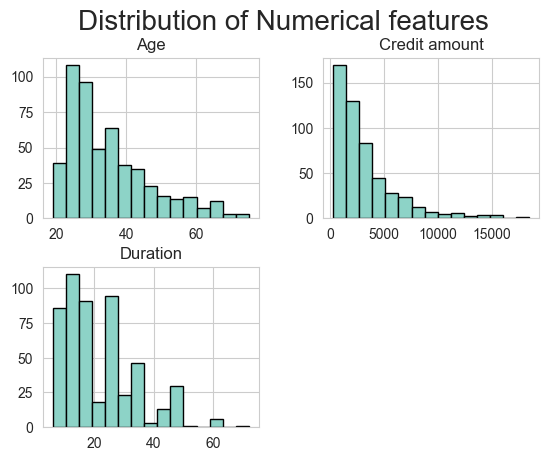

In [19]:
df[["Age", "Credit amount", "Duration"]].hist(bins=15, edgecolor='k')
plt.suptitle("Distribution of Numerical features", fontsize=20)
plt.show()

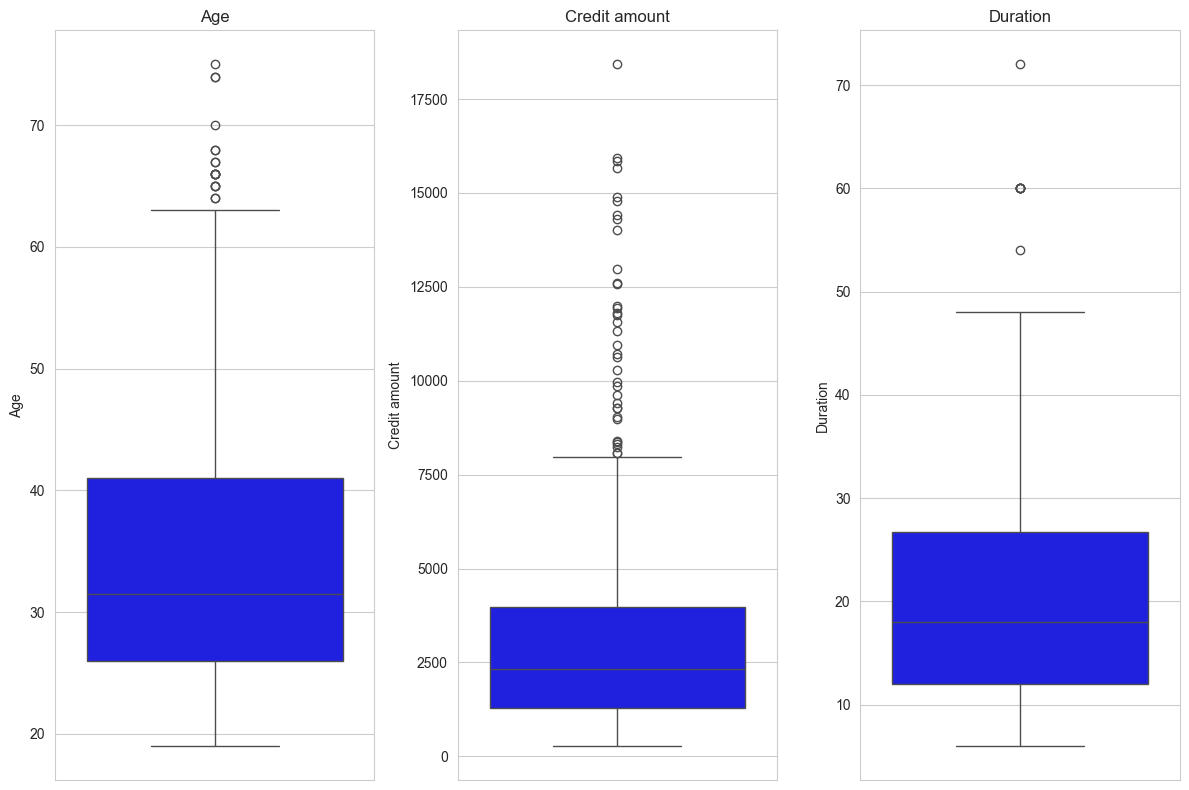

In [20]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(("Age", "Credit amount", "Duration")):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col], color="blue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [21]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [22]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

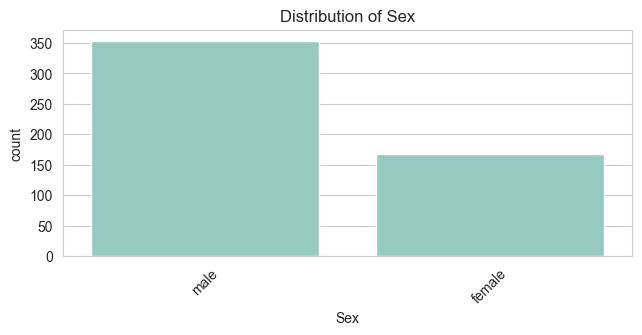

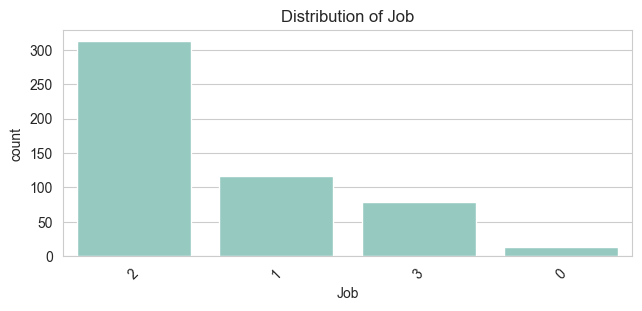

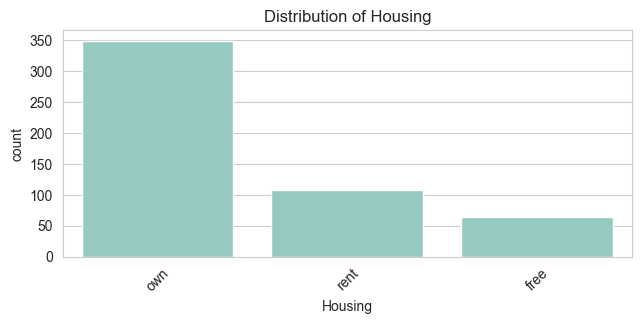

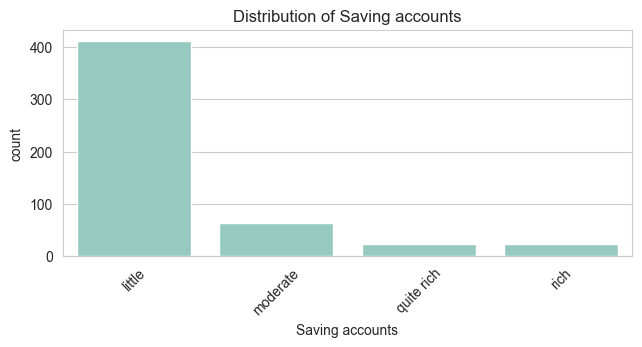

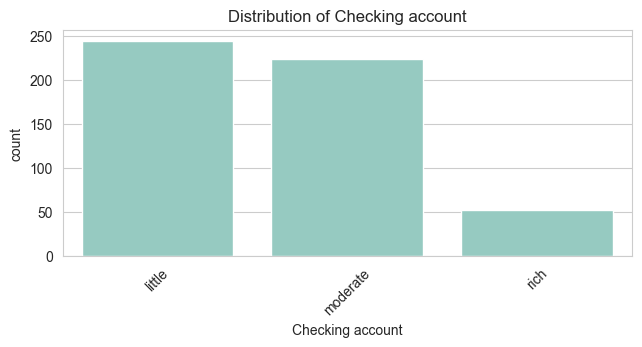

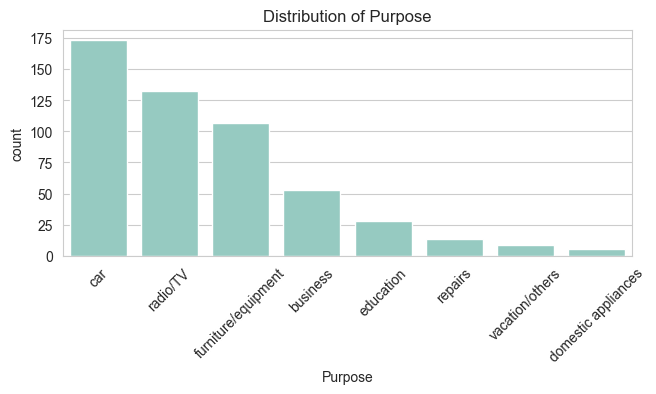

In [23]:
for i, col in enumerate(categorical_cols):
    plt.figure(figsize=(25, 10))
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout
plt.show()

In [24]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

In [25]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


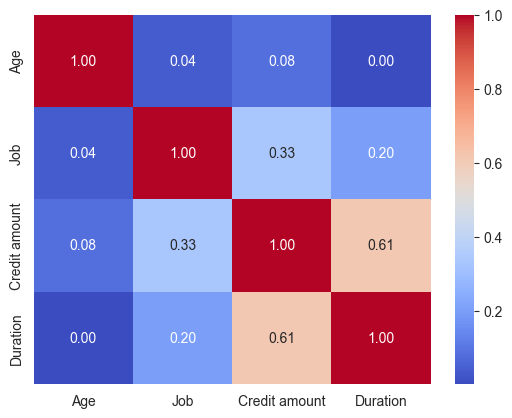

In [26]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [27]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [28]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [29]:
pd.pivot_table(df, values="Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


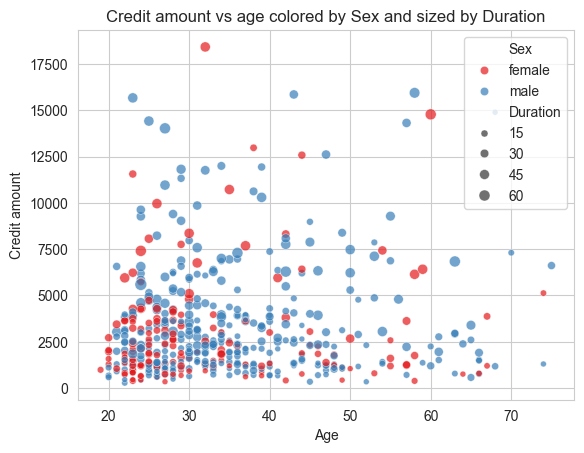

In [30]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit amount vs age colored by Sex and sized by Duration")
plt.show()

C:\Users\48502\AppData\Local\Temp\ipykernel_20564\2345391427.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="pastel")


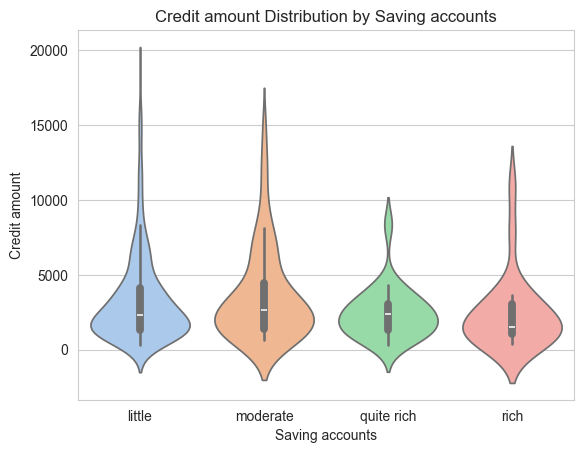

<Figure size 1200x800 with 0 Axes>

In [31]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="pastel")
plt.title("Credit amount Distribution by Saving accounts")
plt.xlabel("Saving accounts")
plt.figure(figsize=(12, 8))
plt.show()

In [32]:
df["Risk"].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

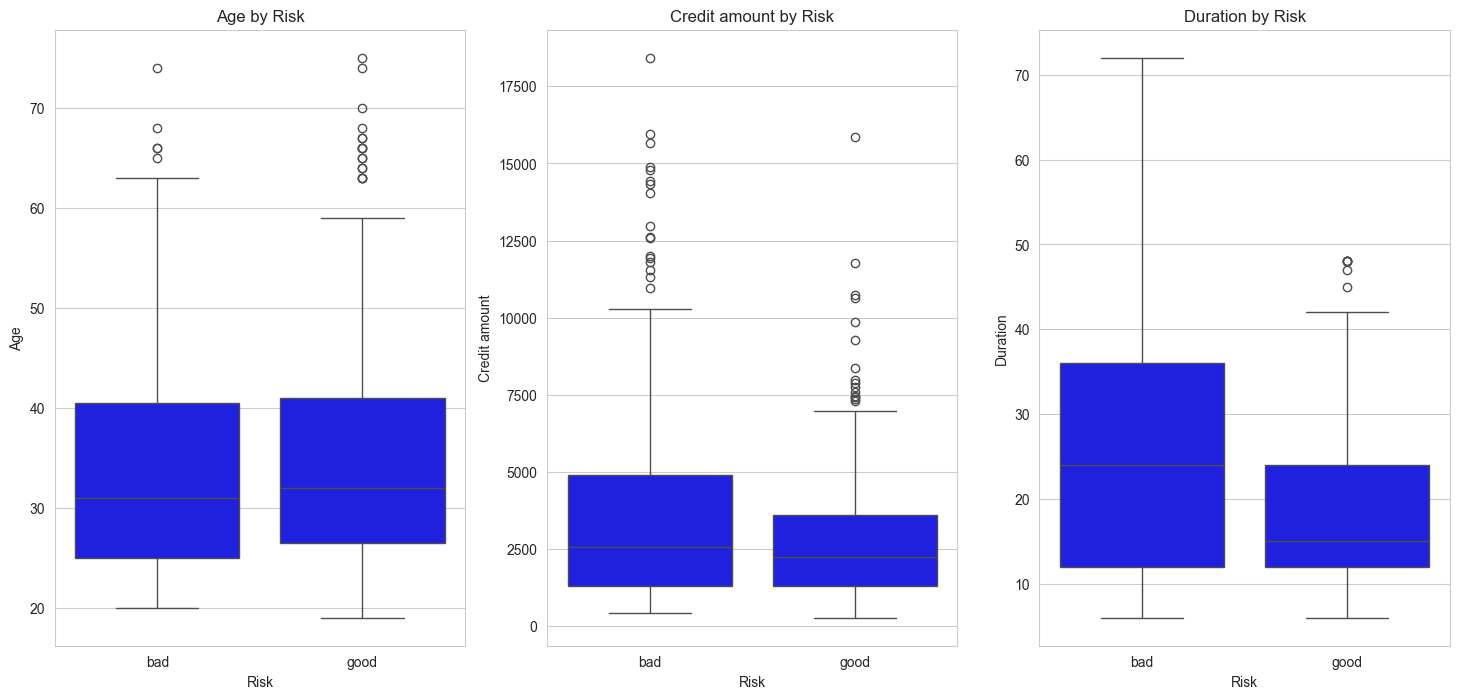

In [33]:
plt.figure(figsize=(18, 8))
for i,col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x="Risk", y=col, color="blue")
    plt.title(f"{col} by Risk")


plt.tight_layout
plt.show()

In [34]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


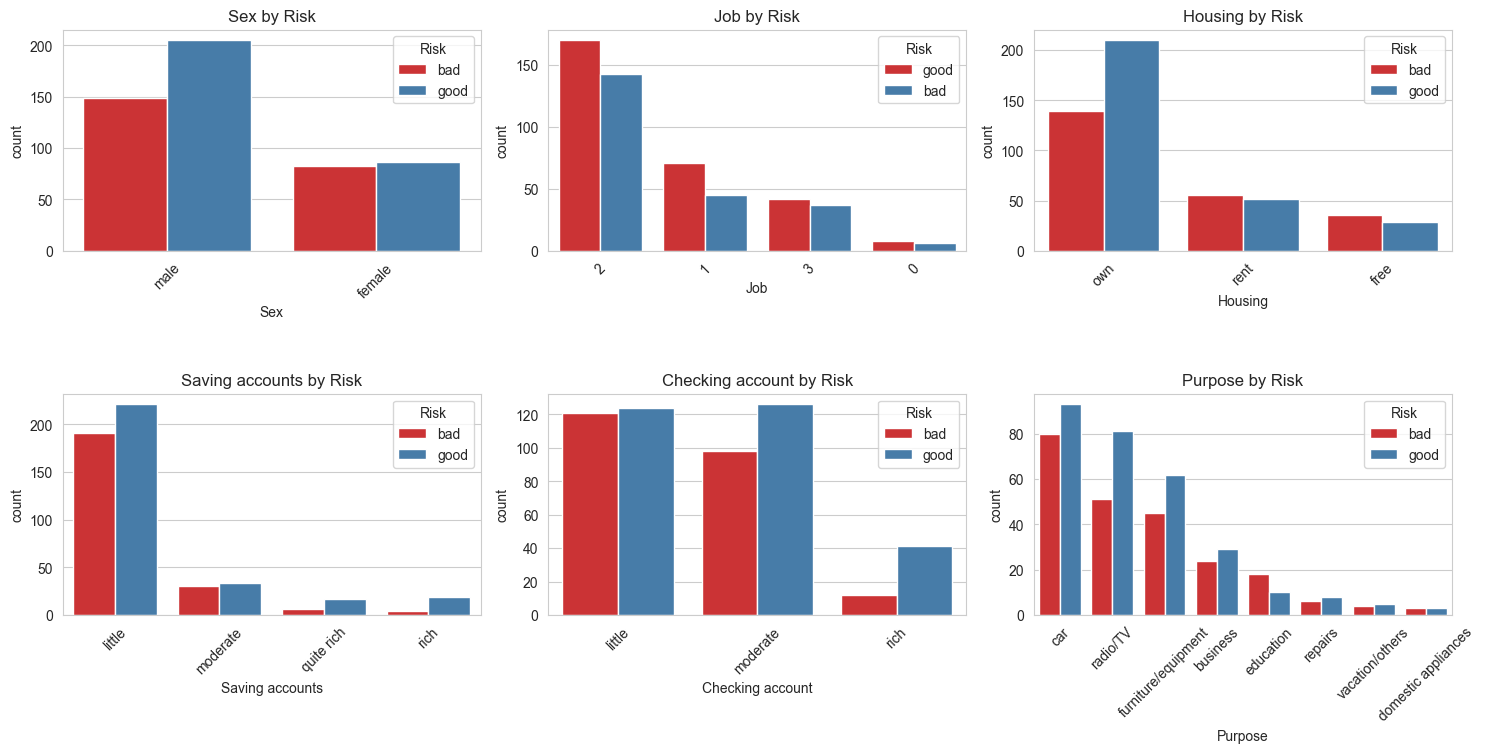

In [35]:
plt.figure(figsize=(15, 10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, hue="Risk", palette="Set1", order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [37]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]

In [38]:
target = "Risk"

In [39]:
df_model = df[features + [target]].copy()

In [40]:
df_model

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad
...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,good
518,30,male,3,own,little,little,3959,36,good
519,40,male,3,own,little,little,3857,30,good
520,23,male,2,free,little,little,1845,45,bad


In [41]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [42]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")

C:\Users\48502\AppData\Local\Temp\ipykernel_20564\714141096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")


In [43]:
le_dict = {}

In [44]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [45]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [46]:
le_target = LabelEncoder()

In [47]:
df_model[target] = le_target.fit_transform(df_model[target])

In [48]:
df_model[target]

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [49]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [50]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [51]:
df_model.head(5)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
x = df_model.drop(target, axis=1)

In [54]:
y = df_model[target]

In [55]:
x

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [56]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [58]:
x_train.shape

(417, 8)

In [59]:
x_test.shape

(105, 8)

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [61]:
def train_model(model, param_grid, x_train, y_train, x_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [62]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 7, 10],
    "min_samples_leaf": [1, 5, 6],
}

In [63]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, x_train, y_train, x_test, y_test)

In [82]:
print("decision tree accuracy", acc_dt)


decision tree accuracy 0.6095238095238096


In [83]:
print("decision tree best parameters:")
print(params_dt)

decision tree best parameters:
{'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [69]:
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [73]:
rf_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "n_estimators": [50, 100, 200],
    "min_samples_split": [2, 7, 10],
    "min_samples_leaf": [1, 4, 5],
    "criterion": ["gini", "entropy"],
}

In [74]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)

In [107]:
print("random forest accuracy", acc_rf)

random forest accuracy 0.6476190476190476


In [78]:
print("random forest best parameters:")
print(params_rf)

random forest best parameters
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [96]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [97]:
et_param_grid = {
    "max_depth": [2, 3, 5, 7, 10, None],
    "n_estimators": [50, 100, 200],
    "min_samples_split": [2, 7, 8, 4, 10],
    "min_samples_leaf": [1, 4, 5, 7, 2],
    "criterion": ["gini", "entropy"],
}

In [102]:
best_et, acc_et, params_et = train_model(et, et_param_grid, x_train, y_train, x_test, y_test)

In [105]:
print("extra trees accuracy", acc_et)

extra trees accuracy 0.6095238095238096


In [106]:
print("extra trees best parameters:")
print(params_et)

extra trees best parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


In [90]:
xgb = XGBClassifier(random_state=1, scale_pos_weight= (y_train==0).sum() / (y_train==1).sum(), eval_metric="logloss")

In [91]:
xgb_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.5, 1],
    "colsample_bytree": [0.5, 1],
}

In [92]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, x_train, y_train, x_test, y_test)

In [94]:
print("xgboost accuracy", acc_xgb)

xgboost accuracy 0.6476190476190476


In [95]:
print("xgboost best parameters:")
print(params_xgb)

xgboost best parameters:
{'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.5}


In [109]:
joblib.dump(best_rf, "rf_model_credit.pkl")

['rf_model_credit.pkl']